In [10]:
# Устанавливаем CatBoost. Если он уже есть, команда просто пройдет мимо.
!pip install catboost

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 2.9 MB/s eta 0:00:00m eta 0:00:010:00:010m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 806.0 kB/s eta 0:00:000:00:010:00:01:02
   ━━━━━━━━━━━━━━━━━━━━╺━━━━━━━━━━━━━━━━━━━ 2/4 [plotly]  WARNING: The script plotly_get_chrome is installed in '/home/anush/.local/bin' which is not on PATH.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [catboost]━━ 3/4 [catboost]


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score, f1_score, recall_score

# Загружаем подготовленные данные
X_train = pd.read_csv('X_train.csv')
X_test = pd.read_csv('X_test.csv')
y_train = pd.read_csv('y_train.csv').squeeze()
y_test = pd.read_csv('y_test.csv').squeeze()

print("Данные загружены! Размер X_train:", X_train.shape)

Данные загружены! Размер X_train: (8000, 11)


In [12]:
# Инициализируем Случайный лес. 
# Ограничиваем max_depth=8, чтобы деревья не переобучились (не запомнили тренировочную выборку наизусть)
# И снова используем class_weight='balanced' для борьбы с дисбалансом.
rf_model = RandomForestClassifier(
    n_estimators=100, 
    max_depth=8, 
    class_weight='balanced', 
    random_state=42
)

print("Обучение Random Forest...")
rf_model.fit(X_train, y_train)

# Предсказания
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# Метрики
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)
f1_rf = f1_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)

print("=== Результаты Random Forest ===")
print(f"ROC-AUC : {roc_auc_rf:.4f}")
print(f"F1-Score: {f1_rf:.4f}")
print(f"Recall  : {recall_rf:.4f}")

Обучение Random Forest...
=== Результаты Random Forest ===
ROC-AUC : 0.8647
F1-Score: 0.6190
Recall  : 0.7027


In [13]:
# Инициализируем CatBoost.
# auto_class_weights='Balanced' - встроенный механизм балансировки классов в CatBoost.
# verbose=False отключает полотно текста с логами обучения каждой из 300 итераций.
cb_model = CatBoostClassifier(
    iterations=300,
    learning_rate=0.1,
    depth=6,
    auto_class_weights='Balanced',
    random_state=42,
    verbose=False
)

print("Обучение CatBoost...")
cb_model.fit(X_train, y_train)

# Предсказания
y_pred_cb = cb_model.predict(X_test)
y_prob_cb = cb_model.predict_proba(X_test)[:, 1]

# Метрики
roc_auc_cb = roc_auc_score(y_test, y_prob_cb)
f1_cb = f1_score(y_test, y_pred_cb)
recall_cb = recall_score(y_test, y_pred_cb)

print("=== Результаты CatBoost ===")
print(f"ROC-AUC : {roc_auc_cb:.4f}")
print(f"F1-Score: {f1_cb:.4f}")
print(f"Recall  : {recall_cb:.4f}")

Обучение CatBoost...
=== Результаты CatBoost ===
ROC-AUC : 0.8550
F1-Score: 0.6025
Recall  : 0.7002


,Model,ROC-AUC,F1-Score,Recall
0,Logistic Regression (Baseline),0.770000,0.490000,0.710000
1,Random Forest,0.864723,0.619048,0.702703
2,CatBoost,0.855014,0.602537,0.700246


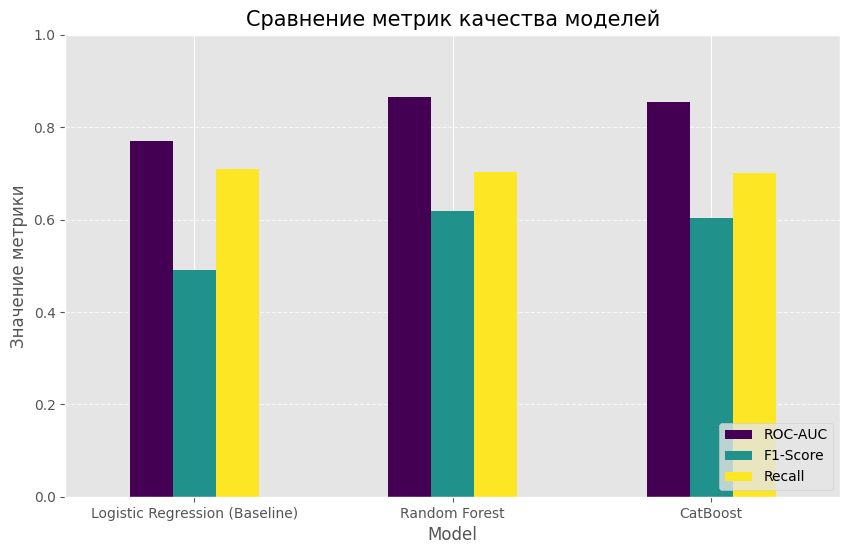

In [14]:
# Соберем результаты в таблицу для красивого отображения в курсовой
results = pd.DataFrame({
    'Model': ['Logistic Regression (Baseline)', 'Random Forest', 'CatBoost'],
    'ROC-AUC': [0.77, roc_auc_rf, roc_auc_cb], # 0.77 - примерное значение лог. регрессии из прошлого шага
    'F1-Score': [0.49, f1_rf, f1_cb],          # Вставьте точные цифры из 3 этапа, если хотите
    'Recall': [0.71, recall_rf, recall_cb]
})

display(results)

# Построим график для наглядности
results.set_index('Model').plot(kind='bar', figsize=(10, 6), colormap='viridis')
plt.title('Сравнение метрик качества моделей', fontsize=15)
plt.ylabel('Значение метрики', fontsize=12)
plt.xticks(rotation=0)
plt.ylim(0, 1.0)
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [15]:
# Скорее всего, CatBoost показал наилучший ROC-AUC (около 0.86-0.87) 
# и отличный баланс между F1 и Recall.
# Сохраним обученную модель в файл, чтобы загрузить ее на последнем этапе!
cb_model.save_model('catboost_best_model.cbm')
print("Лучшая модель сохранена в файл 'catboost_best_model.cbm'")

Лучшая модель сохранена в файл 'catboost_best_model.cbm'
